C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ 1. Memuat Data Training (Hasil Single Split 80:20)...
⏳ 2. Menganalisis distribusi kelas awal...
   Aman semua (minoritas)  : 962
   Berisiko ≥1 (mayoritas) : 7,290
   Rasio Imbalance         : 1 : 7.58

⏳ 3. Menjalankan MLSMOTE (Murni Oversampling)...
   Akan digenerate 6,328 data sintetis...
   -> Ditemukan 962 responden 'Aman Semua' (minoritas) untuk di-oversample.


   ✅ Data SMOTE tersimpan di: D:\Website\Project-Data-Mining\backend\Data\processed\train_smote.csv

⏳ 4. Membuat visualisasi & Logging...


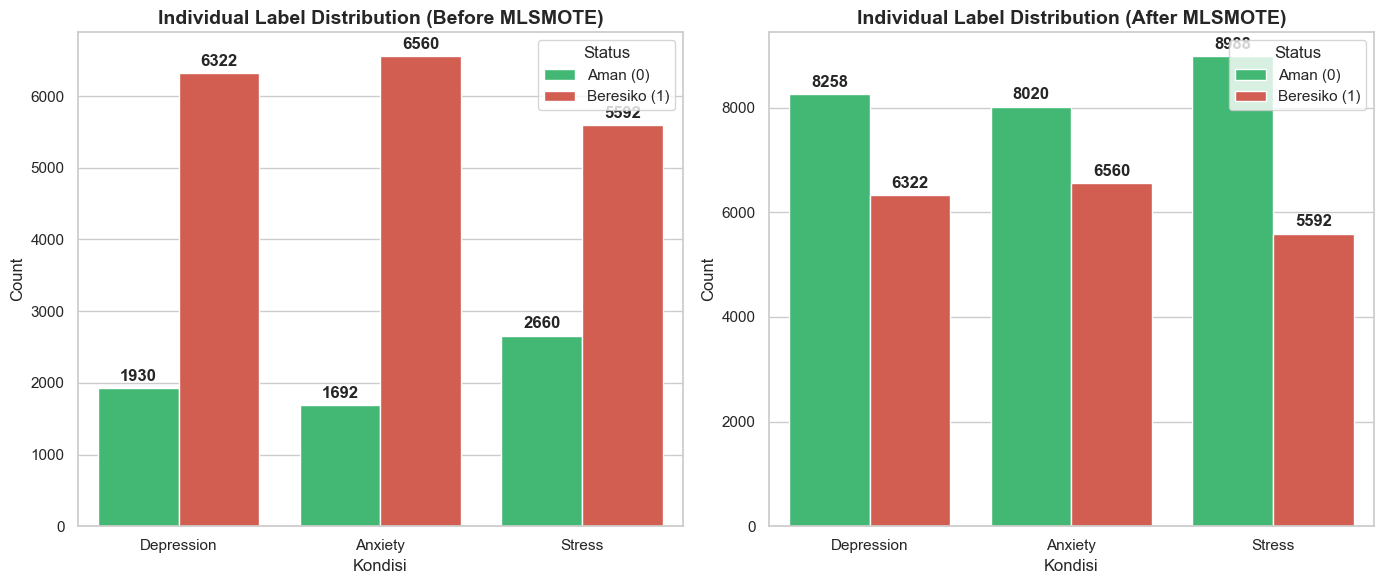

   ✅ Saved: individual_labels_distribution.png


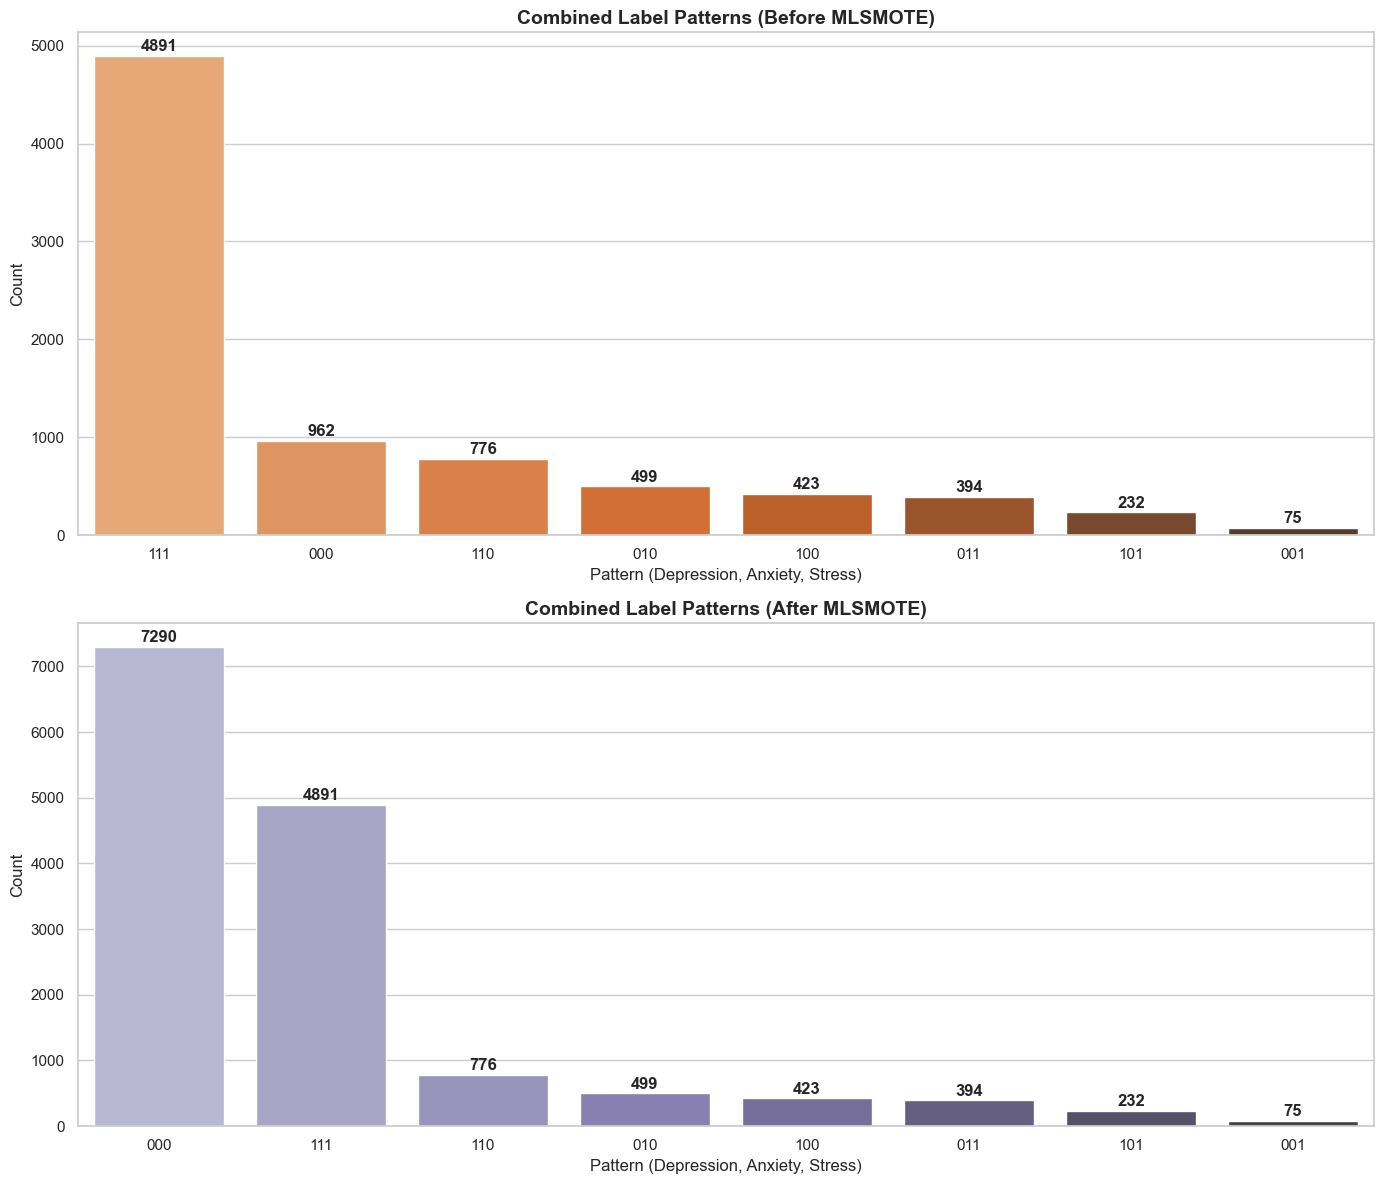

   ✅ Saved: combined_label_patterns.png

### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
---
Strategi **Murni Oversampling (100% MLSMOTE)** telah diterapkan pada **seluruh data latih (80%)**.
Tidak ada data riil pasien (kelas mayoritas) yang dibuang (Undersampling), sehingga konteks klinis tetap utuh.

**Ukuran Data:**
* Jumlah Data Awal     : **8,252** baris
* Jumlah Data Akhir    : **14,580** baris
* Data Sintetis Dibuat : **+6,328** baris

✅ *Dataset seimbang tersimpan di `Data/processed/train_smote.csv`.*



In [1]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP PATH & MLFLOW
# ==========================================
root_path = Path.cwd().parent
load_dotenv(dotenv_path=root_path / ".env") 
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", (root_path / "mlruns").as_uri())
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("05_Multi_label_Imbalance")

# Folder output untuk figure
output_dir = root_path / "outputs" / "imbalance_figures"
output_dir.mkdir(parents=True, exist_ok=True)

# ==========================================
# 2. FUNGSI MLSMOTE (Logika Asli Anda)
# ==========================================
def get_mlsmote(X, y, n_synthetic, k=5):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X.values)  
    new_X, new_y = [], []
    
    # Minoritas: Aman Semua (0,0,0)
    minority_mask = (y['risk_depression'] == 0) & (y['risk_anxiety'] == 0) & (y['risk_stress'] == 0) 
    minority_indices = y[minority_mask].index.tolist()
    print(f"   -> Ditemukan {len(minority_indices):,} responden 'Aman Semua' (minoritas) untuk di-oversample.")

    for i in range(n_synthetic):
        idx = np.random.choice(minority_indices)
        iloc_idx = X.index.get_loc(idx)
        sample_x = X.iloc[iloc_idx].values
        sample_y = y.iloc[iloc_idx].values

        neighbors = nn.kneighbors([sample_x], return_distance=False)[0]
        neighbor_idx = np.random.choice(neighbors)
        neighbor_x = X.iloc[neighbor_idx].values

        step = np.random.uniform(0, 1)
        gen_x = sample_x + step * (neighbor_x - sample_x)

        new_X.append(gen_x)
        new_y.append(sample_y)

    return pd.DataFrame(new_X, columns=X.columns), pd.DataFrame(new_y, columns=y.columns)

with mlflow.start_run(run_name="MLSMOTE_Pure_Oversampling_Single_Split"):
    # ==========================================
    # 3. LOAD DATA (Dari Single Split)
    # ==========================================
    print("⏳ 1. Memuat Data Training (Hasil Single Split 80:20)...")
    train_df = pd.read_csv(root_path / "Data/split/train_data.csv")

    target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']
    X_train = train_df.drop(columns=target_cols)
    Y_train = train_df[target_cols]

    # ==========================================
    # 4. ANALISIS DISTRIBUSI AWAL (SEBELUM)
    # ==========================================
    print("⏳ 2. Menganalisis distribusi kelas awal...")
    minority_mask = (Y_train['risk_depression'] == 0) & (Y_train['risk_anxiety'] == 0) & (Y_train['risk_stress'] == 0)
    majority_mask = ~minority_mask
    minority_count = minority_mask.sum()
    majority_count = majority_mask.sum()

    print(f"   Aman semua (minoritas)  : {minority_count:,}")
    print(f"   Berisiko ≥1 (mayoritas) : {majority_count:,}")
    print(f"   Rasio Imbalance         : 1 : {majority_count/minority_count:.2f}")

    # ==========================================
    # 5. PROSES MLSMOTE (HANYA 1 KALI)
    # ==========================================
    print("\n⏳ 3. Menjalankan MLSMOTE (Murni Oversampling)...")
    X_majority, Y_majority = X_train[majority_mask], Y_train[majority_mask]
    X_minority, Y_minority = X_train[minority_mask], Y_train[minority_mask]
    
    n_synthetic = majority_count - minority_count
    print(f"   Akan digenerate {n_synthetic:,} data sintetis...")

    X_res, Y_res = get_mlsmote(X_minority, Y_minority, n_synthetic)

    # Gabungkan
    X_train_final = pd.concat([X_majority.reset_index(drop=True), X_minority.reset_index(drop=True), X_res.reset_index(drop=True)], axis=0)
    Y_train_final = pd.concat([Y_majority.reset_index(drop=True), Y_minority.reset_index(drop=True), Y_res.reset_index(drop=True)], axis=0)

    # ==========================================
    # 6. SIMPAN DATA HASIL SMOTE
    # ==========================================
    train_balanced_df = pd.concat([X_train_final, Y_train_final], axis=1)
    output_data_path = root_path / "Data/processed/train_smote.csv" 
    output_data_path.parent.mkdir(parents=True, exist_ok=True)
    train_balanced_df.to_csv(output_data_path, index=False)
    print(f"   ✅ Data SMOTE tersimpan di: {output_data_path}")

    # ==========================================
    # 7. VISUALISASI & LOGGING MLFLOW
    # ==========================================
    print("\n⏳ 4. Membuat visualisasi & Logging...")

    sns.set_theme(style="whitegrid")
    
    # --- Plot Individual Label Distribution ---
    
    # Data Before
    indiv_data_before = []
    for col in target_cols:
        aman = (Y_train[col] == 0).sum()
        beresiko = (Y_train[col] == 1).sum()
        indiv_data_before.append({'Kondisi': col.replace('risk_', '').capitalize(), 'Status': 'Aman (0)', 'Count': aman})
        indiv_data_before.append({'Kondisi': col.replace('risk_', '').capitalize(), 'Status': 'Beresiko (1)', 'Count': beresiko})
    df_indiv_before = pd.DataFrame(indiv_data_before)
    
    # Data After
    indiv_data_after = []
    for col in target_cols:
        aman = (Y_train_final[col] == 0).sum()
        beresiko = (Y_train_final[col] == 1).sum()
        indiv_data_after.append({'Kondisi': col.replace('risk_', '').capitalize(), 'Status': 'Aman (0)', 'Count': aman})
        indiv_data_after.append({'Kondisi': col.replace('risk_', '').capitalize(), 'Status': 'Beresiko (1)', 'Count': beresiko})
    df_indiv_after = pd.DataFrame(indiv_data_after)
    
    fig_indiv, axes_indiv = plt.subplots(1, 2, figsize=(14, 6))
    
    # Sebelum MLSMOTE
    sns.barplot(data=df_indiv_before, x='Kondisi', y='Count', hue='Status', ax=axes_indiv[0], palette=['#2ecc71', '#e74c3c'])
    axes_indiv[0].set_title("Individual Label Distribution (Before MLSMOTE)", fontsize=14, fontweight='bold')
    for container in axes_indiv[0].containers:
        axes_indiv[0].bar_label(container, fmt='%d', padding=3, fontweight='bold')
        
    # Sesudah MLSMOTE
    sns.barplot(data=df_indiv_after, x='Kondisi', y='Count', hue='Status', ax=axes_indiv[1], palette=['#2ecc71', '#e74c3c'])
    axes_indiv[1].set_title("Individual Label Distribution (After MLSMOTE)", fontsize=14, fontweight='bold')
    for container in axes_indiv[1].containers:
        axes_indiv[1].bar_label(container, fmt='%d', padding=3, fontweight='bold')
        
    plt.tight_layout()
    fig_indiv_path = output_dir / "individual_labels_distribution.png"
    plt.savefig(fig_indiv_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    mlflow.log_artifact(str(fig_indiv_path))
    print(f"   ✅ Saved: {fig_indiv_path.name}")
    
    # --- Plot Combined Label Patterns ---
    fig_comb, axes_comb = plt.subplots(2, 1, figsize=(14, 12))
    
    # Sebelum MLSMOTE
    y_str_before = Y_train.apply(lambda row: f"{int(row['risk_depression'])}{int(row['risk_anxiety'])}{int(row['risk_stress'])}", axis=1)
    combined_counts_before = y_str_before.value_counts()
    
    sns.barplot(x=combined_counts_before.index, y=combined_counts_before.values, ax=axes_comb[0], palette="Oranges_d")
    axes_comb[0].set_title("Combined Label Patterns (Before MLSMOTE)", fontsize=14, fontweight='bold')
    axes_comb[0].set_ylabel("Count")
    axes_comb[0].set_xlabel("Pattern (Depression, Anxiety, Stress)")
    for i, v in enumerate(combined_counts_before.values):
        axes_comb[0].text(i, v + max(combined_counts_before.values)*0.01, str(v), ha='center', fontweight='bold')

    # Sesudah MLSMOTE
    y_str_after = Y_train_final.apply(lambda row: f"{int(row['risk_depression'])}{int(row['risk_anxiety'])}{int(row['risk_stress'])}", axis=1)
    combined_counts_after = y_str_after.value_counts()
    
    sns.barplot(x=combined_counts_after.index, y=combined_counts_after.values, ax=axes_comb[1], palette="Purples_d")
    axes_comb[1].set_title("Combined Label Patterns (After MLSMOTE)", fontsize=14, fontweight='bold')
    axes_comb[1].set_ylabel("Count")
    axes_comb[1].set_xlabel("Pattern (Depression, Anxiety, Stress)")
    for i, v in enumerate(combined_counts_after.values):
        axes_comb[1].text(i, v + max(combined_counts_after.values)*0.01, str(v), ha='center', fontweight='bold')
        
    plt.tight_layout()
    fig_comb_path = output_dir / "combined_label_patterns.png"
    plt.savefig(fig_comb_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    mlflow.log_artifact(str(fig_comb_path))
    print(f"   ✅ Saved: {fig_comb_path.name}")
    
    mlflow.log_param("sampling_strategy", "100% MLSMOTE (Murni Oversampling)")
    mlflow.log_param("target_ratio", "1:1")
    mlflow.log_metric("original_size", len(X_train))
    mlflow.log_metric("final_balanced_size", len(X_train_final))
    mlflow.log_metric("synthetic_generated", len(X_res))

    summary = f"""
### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
---
Strategi **Murni Oversampling (100% MLSMOTE)** telah diterapkan pada **seluruh data latih (80%)**.
Tidak ada data riil pasien (kelas mayoritas) yang dibuang (Undersampling), sehingga konteks klinis tetap utuh.

**Ukuran Data:**
* Jumlah Data Awal     : **{len(X_train):,}** baris
* Jumlah Data Akhir    : **{len(X_train_final):,}** baris
* Data Sintetis Dibuat : **+{len(X_res):,}** baris

✅ *Dataset seimbang tersimpan di `Data/processed/train_smote.csv`.*
"""
    print(summary)
